<a href="https://colab.research.google.com/github/sevcenkolera/sevcenko/blob/main/kontrolna_Shevchenko1zavd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('Global YouTube Statistics.csv', encoding='latin-1')

In [ ]:
# 2. Перші 5 рядків
print(df.head())

   rank                    Youtuber  subscribers   video views  \
0     1                    T-Series    245000000  2.280000e+11   
1     2              YouTube Movies    170000000  0.000000e+00   
2     3                     MrBeast    166000000  2.836884e+10   
3     4  Cocomelon - Nursery Rhymes    162000000  1.640000e+11   
4     5                   SET India    159000000  1.480000e+11   

           category                       Title  uploads        Country  \
0             Music                    T-Series    20082          India   
1  Film & Animation               youtubemovies        1  United States   
2     Entertainment                     MrBeast      741  United States   
3         Education  Cocomelon - Nursery Rhymes      966  United States   
4             Shows                   SET India   116536          India   

  Abbreviation   channel_type  ...  subscribers_for_last_30_days  \
0           IN          Music  ...                     2000000.0   
1           US  

In [ ]:
# 3. Розміри, пропуски, дублікати
print("\nРозмір:", df.shape)
print("\nПропуски:\n", df.isnull().sum())
print("\nДублікати:", df.duplicated().sum())


Розмір: (995, 28)

Пропуски:
 rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month                

In [ ]:
# 4. Заповнення пропусків середнім

numeric_cols = ['subscribers', 'video views', 'uploads']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].mean())

print("Обробка пропусків виконана")
print(df[numeric_cols].head())

Обробка пропусків виконана
   subscribers   video views  uploads
0    245000000  2.280000e+11    20082
1    170000000  0.000000e+00        1
2    166000000  2.836884e+10      741
3    162000000  1.640000e+11      966
4    159000000  1.480000e+11   116536


In [ ]:
# 5. Перевірка ще раз
print("Пропуски після обробки:")
print(df.isnull().sum())

Пропуски після обробки:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month                       

In [ ]:
# 6. Унікальні країни
df['Country'].nunique()

49

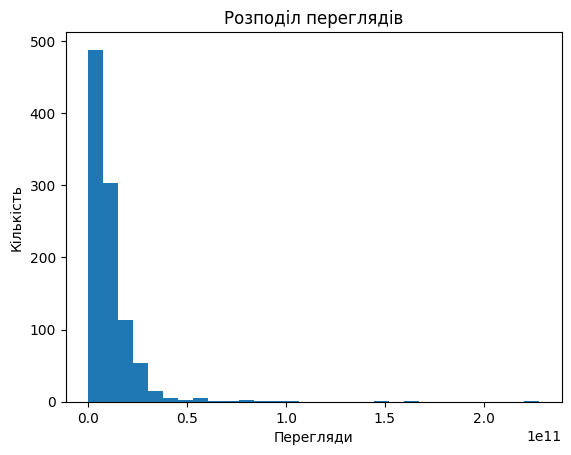

In [ ]:
# 7. Гістограма переглядів
import matplotlib.pyplot as plt

df['video views'].plot(kind='hist', bins=30)
plt.title("Розподіл переглядів")
plt.xlabel("Перегляди")
plt.ylabel("Кількість")
plt.show()

In [ ]:
# 8. max, min, mean
print("\nMax:", df['video views'].max())
print("Min:", df['video views'].min())
print("Mean:", df['video views'].mean())


Max: 228000000000.0
Min: 0.0
Mean: 11039537052.03819


In [ ]:
# 9. Країна з найбільшим uploads
country_uploads = df.groupby('Country')['uploads'].sum()
print("\nКраїна з найбільшим uploads:", country_uploads.idxmax())


Країна з найбільшим uploads: India


In [ ]:
# 10. Відео з max/min uploads
print("\nНайбільше uploads:", df.loc[df['uploads'].idxmax(), 'Title'])
print("Найменше uploads:", df.loc[df['uploads'].idxmin(), 'Title'])


Найбільше uploads: ABP NEWS
Найменше uploads: Music
